# Chapter 44 — Re-Track with Rescued Division Daughters

Chapter 43 recovered daughter-like detections that Chapter 36 had removed. This notebook re-tracks the experimental Chapter 43 detection set and compares the resulting tracks with Chapter 37 around the known GT division.

## Known GT division

```text
GT parent:      172000000050   t=66
GT daughter A:  173000000050   t=67
GT daughter B:  173000000051   t=67
```

## Expected inputs

The notebook searches `/kaggle/working` and `/kaggle/input` for:

```text
chapter43_rescued_detection_set.csv
chapter43_rescued_detections.csv
chapter37_refined_track_nodes.csv
chapter37_refined_track_summary.csv
```

## Main outputs

```text
chapter44_retracked_track_nodes.csv
chapter44_retracked_track_edges.csv
chapter44_retracked_track_summary.csv
chapter44_division_daughter_diagnostics.csv
chapter44_before_after_division_comparison.csv
chapter44_outputs.zip
```

In [1]:

!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.9 MB/s eta 0:00:00


In [2]:

from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
import shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from scipy.optimize import linear_sum_assignment
from IPython.display import display
warnings.filterwarnings("ignore")

## Step 1 — Configuration

In [3]:

@dataclass(frozen=True)
class TrackingConfig:
    sample_id: str = "44b6_12dfb391"
    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625
    max_link_distance: float = 9.0
    max_link_distance_with_velocity: float = 12.0
    max_gap: int = 2
    max_gap_distance: float = 15.0
    velocity_weight: float = 0.70
    spatial_weight: float = 0.30
    division_parent_t: int = 66
    division_daughter_t: int = 67
    daughter_search_start_t: int = 66
    daughter_search_end_t: int = 70
    daughter_distance_threshold: float = 10.0

CONFIG = TrackingConfig()
OUTPUT_DIR = Path('/kaggle/working'); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(CONFIG)

TrackingConfig(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, max_link_distance=9.0, max_link_distance_with_velocity=12.0, max_gap=2, max_gap_distance=15.0, velocity_weight=0.7, spatial_weight=0.3, division_parent_t=66, division_daughter_t=67, daughter_search_start_t=66, daughter_search_end_t=70, daughter_distance_threshold=10.0)


## Step 2 — Locate Chapter 43 and Chapter 37 files

In [4]:
# ============================================================
# STEP 2 — LOCATE CHAPTER 43 AND CHAPTER 37 INPUTS
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Explicit Kaggle folders
# ------------------------------------------------------------

DATA43_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/43data"
)

DATA37_DIR = Path(
    "/kaggle/input/datasets/emailchrismathews/data37"
)

OUTPUT_DIR = Path(
    "/kaggle/working"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def find_file(
    folder,
    filename,
    required=False,
):
    folder = Path(folder)

    # Try exact path first
    direct = folder / filename

    if direct.exists():
        return direct

    # Then search recursively
    matches = []

    if folder.exists():
        matches = list(
            folder.rglob(filename)
        )

    if matches:
        return sorted(
            matches,
            key=lambda path: len(str(path)),
        )[0]

    if required:
        raise FileNotFoundError(
            f"Could not find required file:\\n"
            f"{filename}\\n\\n"
            f"Folder searched:\\n"
            f"{folder}"
        )

    return None


# ------------------------------------------------------------
# Locate files
# ------------------------------------------------------------

paths = {
    "rescued_set": find_file(
        DATA43_DIR,
        "chapter43_rescued_detection_set.csv",
        required=True,
    ),

    "rescued_only": find_file(
        DATA43_DIR,
        "chapter43_rescued_detections.csv",
        required=False,
    ),

    "baseline_nodes": find_file(
        DATA37_DIR,
        "chapter37_refined_track_nodes.csv",
        required=True,
    ),

    "baseline_summary": find_file(
        DATA37_DIR,
        "chapter37_refined_track_summary.csv",
        required=False,
    ),
}


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("=" * 80)
print("CHAPTER 44 INPUT CHECK")
print("=" * 80)

for name, path in paths.items():

    status = (
        "FOUND"
        if path is not None
        else "NOT FOUND"
    )

    print()
    print(f"{name}: {status}")

    if path is not None:
        print(f"  {path}")


print()
print("=" * 80)

if paths["rescued_set"] is not None:
    print("✓ Chapter 43 rescued detection set is ready.")

if paths["baseline_nodes"] is not None:
    print("✓ Chapter 37 baseline tracks are ready.")

print()
print("Chapter 44 inputs successfully located.")

CHAPTER 44 INPUT CHECK

rescued_set: FOUND
  /kaggle/input/datasets/emailchrismathews/43data/chapter43_rescued_detection_set.csv

rescued_only: FOUND
  /kaggle/input/datasets/emailchrismathews/43data/chapter43_rescued_detections.csv

baseline_nodes: FOUND
  /kaggle/input/datasets/emailchrismathews/data37/chapter37_refined_track_nodes.csv

baseline_summary: NOT FOUND

✓ Chapter 43 rescued detection set is ready.
✓ Chapter 37 baseline tracks are ready.

Chapter 44 inputs successfully located.


## Step 3 — Load detections and baseline tracks

In [5]:

detections_df=pd.read_csv(paths['rescued_set'])
rescued_only_df=pd.read_csv(paths['rescued_only']) if paths['rescued_only'] else pd.DataFrame()
baseline_nodes_df=pd.read_csv(paths['baseline_nodes']) if paths['baseline_nodes'] else pd.DataFrame()
baseline_summary_df=pd.read_csv(paths['baseline_summary']) if paths['baseline_summary'] else pd.DataFrame()
print('Rescued detection set:',len(detections_df))
print('Rescued-only rows:',len(rescued_only_df))
print('Baseline nodes:',len(baseline_nodes_df))
display(detections_df.head())

Rescued detection set: 5004
Rescued-only rows: 4
Baseline nodes: 4642


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,...,temporal_support_score,is_isolated,nearest_gt_dist,oracle_good,temporal_model_probability,final_filter_score,filtered_rank_position,z_physical,y_physical,x_physical
0,7,241,51,3.750000,2,medium_sensitive|medium_strict,1364.0,1364.0,1170.234619,1403.0,...,0.601002,0.0,5.385165,True,0.945161,0.807498,1.0,11.375,97.90625,20.71875
1,27,212,110,3.833333,3,large_sensitive|medium_sensitive|medium_strict,1865.0,1865.0,1605.333374,1935.0,...,0.597439,0.0,1.414214,True,0.945161,0.806073,2.0,43.875,86.12500,44.68750
2,38,192,91,5.000000,1,large_sensitive,1654.0,1654.0,1582.654297,1770.0,...,0.593334,0.0,7.681146,False,0.944917,0.804284,3.0,61.750,78.00000,36.96875
3,37,196,98,3.500000,1,medium_sensitive,1476.0,1476.0,1372.839478,1579.0,...,0.581407,0.0,5.385165,True,0.945161,0.799660,4.0,60.125,79.62500,39.81250
4,41,130,131,4.000000,1,medium_strict,1754.0,1754.0,1583.678955,1790.0,...,0.579070,0.0,3.316625,True,0.944917,0.798578,5.0,66.625,52.81250,53.21875


## Step 4 — Normalize columns and physical coordinates

In [6]:

required={'t','z','y','x'}
missing=required-set(detections_df.columns)
if missing: raise ValueError(f'Missing columns: {sorted(missing)}')
if 'detection_id' not in detections_df.columns:
    detections_df=detections_df.reset_index(drop=True).copy()
    detections_df['detection_id']=[f'chapter44_det_{i}' for i in range(len(detections_df))]

def add_physical_coordinates(df):
    out=df.copy(); out['z_physical']=out['z'].astype(float)*CONFIG.z_scale; out['y_physical']=out['y'].astype(float)*CONFIG.y_scale; out['x_physical']=out['x'].astype(float)*CONFIG.x_scale; return out

detections_df=add_physical_coordinates(detections_df)
detections_df['t']=detections_df['t'].astype(int)
detections_df=detections_df.sort_values(['t','detection_id']).reset_index(drop=True)
print('Frames:',detections_df.t.min(),'to',detections_df.t.max())
print('Mean detections/frame:',detections_df.groupby('t').size().mean())

Frames: 0 to 99
Mean detections/frame: 50.04


## Step 5 — Load the known GEFF division

In [7]:

def find_geff_path(sample_id):
    p=Path('/kaggle/input/competitions/biohub-cell-tracking-during-development/train')/f'{sample_id}.geff'
    if p.exists(): return p
    matches=list(Path('/kaggle/input').rglob(f'{sample_id}.geff'))
    if matches: return sorted(matches,key=lambda p:len(str(p)))[0]
    raise FileNotFoundError(f'Could not find GEFF for {sample_id}')

geff_path=find_geff_path(CONFIG.sample_id); geff=zarr.open(geff_path,mode='r')
gt_nodes_df=pd.DataFrame({'gt_node_id':np.asarray(geff['nodes/ids'][:]),'t':np.asarray(geff['nodes/props/t/values'][:]).astype(int),'z':np.asarray(geff['nodes/props/z/values'][:]).astype(float),'y':np.asarray(geff['nodes/props/y/values'][:]).astype(float),'x':np.asarray(geff['nodes/props/x/values'][:]).astype(float)})
edge_ids=np.asarray(geff['edges/ids'][:]); gt_edges_df=pd.DataFrame({'gt_source':edge_ids[:,0],'gt_target':edge_ids[:,1]})
out_degree=gt_edges_df.groupby('gt_source').size(); rows=[]
for parent in out_degree[out_degree==2].index:
    ds=sorted(gt_edges_df.loc[gt_edges_df.gt_source==parent,'gt_target'].tolist())
    if len(ds)!=2: continue
    p=gt_nodes_df[gt_nodes_df.gt_node_id==parent]; a=gt_nodes_df[gt_nodes_df.gt_node_id==ds[0]]; b=gt_nodes_df[gt_nodes_df.gt_node_id==ds[1]]
    if p.empty or a.empty or b.empty: continue
    p,a,b=p.iloc[0],a.iloc[0],b.iloc[0]
    rows.append({'gt_parent':parent,'gt_daughter_a':ds[0],'gt_daughter_b':ds[1],'parent_t':int(p.t),'daughter_t_a':int(a.t),'daughter_t_b':int(b.t),'parent_z':float(p.z),'parent_y':float(p.y),'parent_x':float(p.x),'daughter_a_z':float(a.z),'daughter_a_y':float(a.y),'daughter_a_x':float(a.x),'daughter_b_z':float(b.z),'daughter_b_y':float(b.y),'daughter_b_x':float(b.x)})
gt_divisions_df=pd.DataFrame(rows)
if gt_divisions_df.empty: raise RuntimeError('No GT division found.')
division=gt_divisions_df.iloc[0]
display(gt_divisions_df)

,gt_parent,gt_daughter_a,gt_daughter_b,parent_t,daughter_t_a,daughter_t_b,parent_z,parent_y,parent_x,daughter_a_z,daughter_a_y,daughter_a_x,daughter_b_z,daughter_b_y,daughter_b_x
0,172000000050,173000000050,173000000051,66,67,67,46.0,63.0,160.0,46.0,51.0,160.0,46.0,74.0,164.0


## Step 6 — Tracking helpers

In [8]:

PHYSICAL_COLUMNS=['z_physical','y_physical','x_physical']
def xyz_from_row(row): return np.array([float(row['z_physical']),float(row['y_physical']),float(row['x_physical'])],dtype=np.float32)
def track_velocity(rows):
    if len(rows)<2: return np.zeros(3,dtype=np.float32)
    dt=max(int(rows[-1]['t'])-int(rows[-2]['t']),1)
    return (xyz_from_row(rows[-1])-xyz_from_row(rows[-2]))/float(dt)
def predict_position(rows,target_t):
    return xyz_from_row(rows[-1])+track_velocity(rows)*(int(target_t)-int(rows[-1]['t']))

## Step 7 — Re-track all rescued detections

In [9]:

def retrack_detections(detections,config=CONFIG):
    detections=detections.sort_values(['t','detection_id']).reset_index(drop=True)
    tracks={}; active=set(); next_id=0; edges=[]
    for t in sorted(detections.t.unique()):
        current=detections[detections.t==t].reset_index(drop=True)
        xyz=current[PHYSICAL_COLUMNS].to_numpy(np.float32)
        eligible=[]
        for tid in sorted(active):
            gap=int(t)-int(tracks[tid][-1]['t'])
            if 1<=gap<=config.max_gap+1: eligible.append(tid)
        assigned=set()
        if eligible and len(current):
            cost=np.full((len(eligible),len(current)),1e9,np.float32); allowed=np.zeros_like(cost,dtype=bool)
            for i,tid in enumerate(eligible):
                rows=tracks[tid]; last=rows[-1]; gap=int(t)-int(last['t'])
                spatial=np.linalg.norm(xyz-xyz_from_row(last)[None,:],axis=1)
                predicted=np.linalg.norm(xyz-predict_position(rows,t)[None,:],axis=1)
                if len(rows)>=2:
                    c=config.spatial_weight*spatial+config.velocity_weight*predicted
                    maxd=config.max_link_distance_with_velocity if gap==1 else config.max_gap_distance
                else:
                    c=spatial; maxd=config.max_link_distance if gap==1 else config.max_gap_distance
                ok=c<=maxd; cost[i,ok]=c[ok]; allowed[i,ok]=True
            ri,ci=linear_sum_assignment(cost)
            for i,j in zip(ri,ci):
                if not allowed[i,j]: continue
                tid=eligible[i]; det=current.iloc[j].to_dict(); prev=tracks[tid][-1]; det['track_id']=tid; tracks[tid].append(det); assigned.add(int(j))
                edges.append({'track_id':tid,'source_detection_id':prev['detection_id'],'target_detection_id':det['detection_id'],'source_t':int(prev['t']),'target_t':int(det['t']),'frame_gap':int(det['t'])-int(prev['t']),'assignment_cost':float(cost[i,j])})
        for j in range(len(current)):
            if j in assigned: continue
            det=current.iloc[j].to_dict(); det['track_id']=next_id; tracks[next_id]=[det]; active.add(next_id); next_id+=1
        active={tid for tid in active if int(t)-int(tracks[tid][-1]['t'])<=config.max_gap}
        print(f't={int(t):>2}: detections={len(current):>3}, tracks={len(tracks):>4}, active={len(active):>4}')
    nodes=[]
    for tid,rs in tracks.items():
        for r in rs:
            q=r.copy(); q['track_id']=int(tid); nodes.append(q)
    return pd.DataFrame(nodes).sort_values(['track_id','t']).reset_index(drop=True), pd.DataFrame(edges)

retracked_nodes_df,retracked_edges_df=retrack_detections(detections_df)
print('Nodes:',len(retracked_nodes_df),'Edges:',len(retracked_edges_df),'Tracks:',retracked_nodes_df.track_id.nunique())

t= 0: detections= 50, tracks=  50, active=  50
t= 1: detections= 50, tracks=  71, active=  71
t= 2: detections= 50, tracks=  77, active=  77
t= 3: detections= 50, tracks=  84, active=  81
t= 4: detections= 50, tracks=  91, active=  82
t= 5: detections= 50, tracks=  99, active=  81
t= 6: detections= 50, tracks= 107, active=  85
t= 7: detections= 50, tracks= 118, active=  84
t= 8: detections= 50, tracks= 133, active=  93
t= 9: detections= 50, tracks= 139, active=  87
t=10: detections= 50, tracks= 148, active=  84
t=11: detections= 50, tracks= 154, active=  79
t=12: detections= 50, tracks= 168, active=  88
t=13: detections= 50, tracks= 174, active=  83
t=14: detections= 50, tracks= 182, active=  81
t=15: detections= 50, tracks= 187, active=  76
t=16: detections= 50, tracks= 193, active=  76
t=17: detections= 50, tracks= 204, active=  80
t=18: detections= 50, tracks= 213, active=  79
t=19: detections= 50, tracks= 226, active=  85
t=20: detections= 50, tracks= 241, active=  93
t=21: detecti

## Step 8 — Track summary

In [10]:

summary=[]
for tid,g in retracked_nodes_df.groupby('track_id'):
    g=g.sort_values('t'); coords=g[PHYSICAL_COLUMNS].to_numpy(float)
    if len(coords)>1:
        path=float(np.linalg.norm(np.diff(coords,axis=0),axis=1).sum()); net=float(np.linalg.norm(coords[-1]-coords[0]))
    else: path=0.0; net=0.0
    duration=int(g.t.max()-g.t.min()+1)
    summary.append({'track_id':int(tid),'start_t':int(g.t.min()),'end_t':int(g.t.max()),'num_detections':len(g),'duration':duration,'coverage_fraction':len(g)/max(duration,1),'mean_rank':float(g.rank_position.mean()) if 'rank_position' in g.columns else np.nan,'mean_pred_dist':float(g.pred_dist.mean()) if 'pred_dist' in g.columns else np.nan,'path_length_physical':path,'net_displacement_physical':net})
retracked_summary_df=pd.DataFrame(summary).sort_values(['num_detections','duration'],ascending=False).reset_index(drop=True)
display(retracked_summary_df.head(30))

,track_id,start_t,end_t,num_detections,duration,coverage_fraction,mean_rank,mean_pred_dist,path_length_physical,net_displacement_physical
0,194,17,87,46,71,0.647887,59.804348,15.556125,260.001803,38.851606
1,388,37,91,46,55,0.836364,67.782609,15.862436,217.387378,59.808500
2,123,8,46,34,39,0.871795,63.323529,16.017566,152.440913,35.390415
3,347,32,74,33,43,0.767442,67.242424,16.028698,163.134154,12.750038
4,343,31,73,28,43,0.651163,55.928571,15.611742,159.753948,28.509952
5,137,9,47,27,39,0.692308,57.666667,15.588717,124.692919,20.849770
6,613,61,96,26,36,0.722222,52.576923,15.357488,111.454879,22.240101
7,210,18,56,25,39,0.641026,68.600000,15.975509,134.003514,43.339469
8,294,26,57,25,32,0.781250,32.880000,15.352937,67.272335,34.533640
9,669,67,95,24,29,0.827586,56.083333,15.508578,108.128457,14.212945


## Step 9 — Daughter-track diagnostics

In [11]:

def physical_gt_xyz(z,y,x): return np.array([float(z)*CONFIG.z_scale,float(y)*CONFIG.y_scale,float(x)*CONFIG.x_scale],dtype=np.float32)
gt_daughter_xyz={'daughter_a':physical_gt_xyz(division.daughter_a_z,division.daughter_a_y,division.daughter_a_x),'daughter_b':physical_gt_xyz(division.daughter_b_z,division.daughter_b_y,division.daughter_b_x)}

def daughter_track_diagnostics(nodes_df,label):
    rows=[]
    for role,gt_xyz in gt_daughter_xyz.items():
        local=nodes_df[nodes_df.t.between(CONFIG.daughter_search_start_t,CONFIG.daughter_search_end_t)].copy()
        if local.empty: continue
        local['distance_to_gt_physical']=np.linalg.norm(local[PHYSICAL_COLUMNS].to_numpy(np.float32)-gt_xyz[None,:],axis=1)
        for tid,g in local.groupby('track_id'):
            best=g.sort_values('distance_to_gt_physical').iloc[0]; full=nodes_df[nodes_df.track_id==tid].sort_values('t'); start=int(full.t.min()); dist=float(best.distance_to_gt_physical)
            rows.append({'version':label,'role':role,'track_id':int(tid),'track_start_t':start,'track_end_t':int(full.t.max()),'track_length':len(full),'nearest_t_to_gt':int(best.t),'nearest_distance_physical':dist,'started_before_division':start<CONFIG.division_daughter_t,'started_at_or_after_division':start>=CONFIG.division_daughter_t,'within_useful_distance':dist<=CONFIG.daughter_distance_threshold,'mean_rank':float(full.rank_position.mean()) if 'rank_position' in full.columns else np.nan,'mean_pred_dist':float(full.pred_dist.mean()) if 'pred_dist' in full.columns else np.nan})
    out=pd.DataFrame(rows)
    return out.sort_values(['role','nearest_distance_physical','track_start_t']).reset_index(drop=True) if not out.empty else out

retracked_daughter_diagnostics_df=daughter_track_diagnostics(retracked_nodes_df,'chapter44_retracked')
display(retracked_daughter_diagnostics_df.head(40))

,version,role,track_id,track_start_t,track_end_t,track_length,nearest_t_to_gt,nearest_distance_physical,started_before_division,started_at_or_after_division,within_useful_distance,mean_rank,mean_pred_dist
0,chapter44_retracked,daughter_a,646,64,68,5,68,6.563169,True,False,True,91.200000,16.644194
1,chapter44_retracked,daughter_a,573,57,68,7,68,12.980943,True,False,False,95.857143,17.054058
2,chapter44_retracked,daughter_a,558,56,77,12,66,15.781126,True,False,False,65.916667,16.162003
3,chapter44_retracked,daughter_a,689,68,70,2,70,15.947577,False,True,False,122.500000,17.211425
4,chapter44_retracked,daughter_a,570,57,66,10,66,16.975224,True,False,False,71.600000,16.241297
5,chapter44_retracked,daughter_a,688,68,68,1,68,20.446123,False,True,False,83.000000,16.760320
6,chapter44_retracked,daughter_a,651,65,67,2,67,20.686863,True,False,False,25.000000,15.549768
7,chapter44_retracked,daughter_a,619,62,66,3,66,25.125175,True,False,False,64.333333,15.944554
8,chapter44_retracked,daughter_a,703,70,70,1,70,27.342768,False,True,False,82.000000,16.856256
9,chapter44_retracked,daughter_a,697,69,87,11,69,28.625494,False,True,False,70.545455,15.625799


## Step 10 — Compare Chapter 37 vs Chapter 44

In [12]:

parts=[retracked_daughter_diagnostics_df]
if not baseline_nodes_df.empty:
    if 'z_physical' not in baseline_nodes_df.columns: baseline_nodes_df=add_physical_coordinates(baseline_nodes_df)
    baseline_diag=daughter_track_diagnostics(baseline_nodes_df,'chapter37_baseline'); parts.append(baseline_diag)
all_daughter_diagnostics_df=pd.concat(parts,ignore_index=True)
rows=[]
for role in ['daughter_a','daughter_b']:
    for version in all_daughter_diagnostics_df.version.unique():
        s=all_daughter_diagnostics_df[(all_daughter_diagnostics_df.role==role)&(all_daughter_diagnostics_df.version==version)].sort_values('nearest_distance_physical')
        if s.empty: continue
        best=s.iloc[0]; after=s[s.started_at_or_after_division]
        rows.append({'version':version,'role':role,'best_track_id':int(best.track_id),'best_distance_physical':float(best.nearest_distance_physical),'best_track_start_t':int(best.track_start_t),'best_started_after_track_id':int(after.iloc[0].track_id) if not after.empty else np.nan,'best_started_after_distance':float(after.iloc[0].nearest_distance_physical) if not after.empty else np.nan})
before_after_df=pd.DataFrame(rows)
display(before_after_df)

,version,role,best_track_id,best_distance_physical,best_track_start_t,best_started_after_track_id,best_started_after_distance
0,chapter44_retracked,daughter_a,646,6.563169,64,689,15.947577
1,chapter37_baseline,daughter_a,313,15.781126,54,432,15.947577
2,chapter44_retracked,daughter_b,573,6.749132,57,689,13.012690
3,chapter37_baseline,daughter_b,313,11.788252,54,432,13.012690


## Step 11 — Check whether rescued detections were used

In [13]:

usage=[]
if not rescued_only_df.empty:
    keys=set(zip(rescued_only_df.t.astype(int),rescued_only_df.z.astype(float),rescued_only_df.y.astype(float),rescued_only_df.x.astype(float)))
    for r in retracked_nodes_df.itertuples(index=False):
        if (int(r.t),float(r.z),float(r.y),float(r.x)) in keys:
            usage.append({'track_id':int(r.track_id),'detection_id':r.detection_id,'t':int(r.t),'z':float(r.z),'y':float(r.y),'x':float(r.x)})
rescued_usage_df=pd.DataFrame(usage)
print('Rescued detections used:',len(rescued_usage_df)); display(rescued_usage_df)

Rescued detections used: 4


,track_id,detection_id,t,z,y,x
0,573,chapter34_t68_101,68,42.0,78.0,166.0
1,611,chapter34_t65_178,65,42.0,46.0,164.0
2,646,chapter34_t67_191,67,40.0,46.0,158.0
3,646,chapter34_t68_181,68,42.0,49.0,161.0


## Step 12 — Visualize tracks around the division

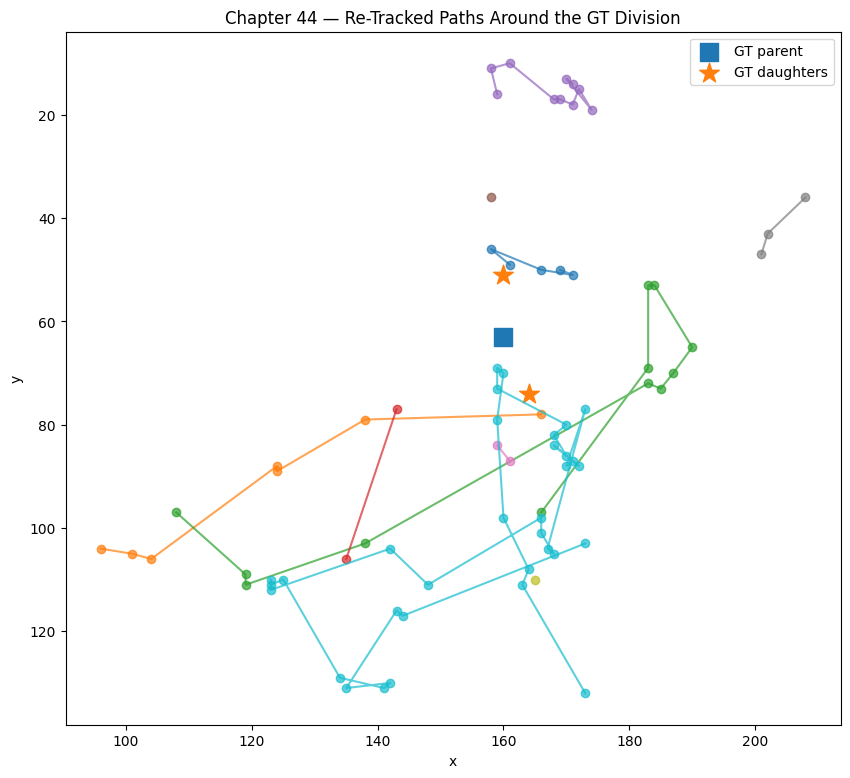

In [14]:

plt.figure(figsize=(10,9))
plt.scatter([division.parent_x],[division.parent_y],marker='s',s=150,label='GT parent')
plt.scatter([division.daughter_a_x,division.daughter_b_x],[division.daughter_a_y,division.daughter_b_y],marker='*',s=220,label='GT daughters')
ids=retracked_daughter_diagnostics_df.groupby('role').head(8).track_id.astype(int).unique()
for tid in ids:
    tr=retracked_nodes_df[retracked_nodes_df.track_id==tid].sort_values('t'); plt.plot(tr.x,tr.y,marker='o',alpha=.7)
plt.gca().invert_yaxis(); plt.xlabel('x'); plt.ylabel('y'); plt.title('Chapter 44 — Re-Tracked Paths Around the GT Division'); plt.legend(); plt.show()

## Step 13 — Track-length comparison

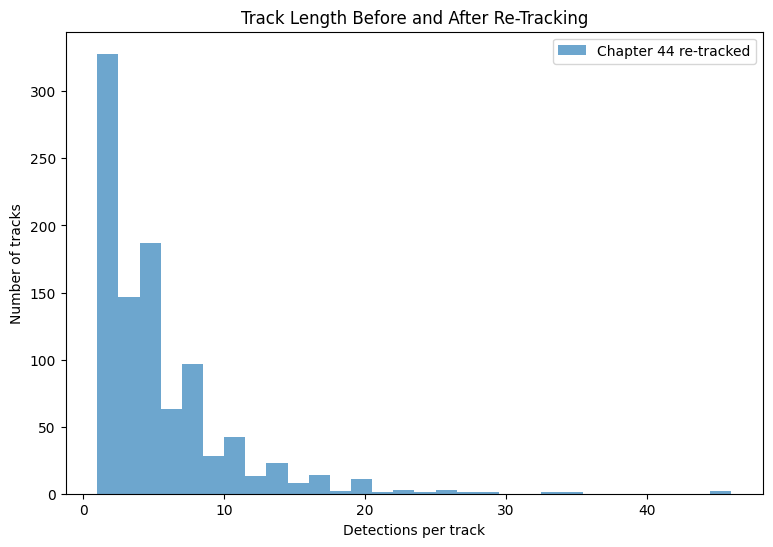

In [15]:

plt.figure(figsize=(9,6)); plt.hist(retracked_summary_df.num_detections,bins=30,alpha=.65,label='Chapter 44 re-tracked')
if not baseline_summary_df.empty:
    c='num_detections' if 'num_detections' in baseline_summary_df.columns else ('num_nodes' if 'num_nodes' in baseline_summary_df.columns else None)
    if c: plt.hist(baseline_summary_df[c],bins=30,alpha=.45,label='Chapter 37 baseline')
plt.xlabel('Detections per track'); plt.ylabel('Number of tracks'); plt.title('Track Length Before and After Re-Tracking'); plt.legend(); plt.show()

## Step 14 — Validation

In [16]:

validation_df=pd.DataFrame([
 {'check':'rescued_detection_set_loaded','passed':len(detections_df)>0,'details':f'{len(detections_df)} detections'},
 {'check':'tracking_created_nodes','passed':len(retracked_nodes_df)>0,'details':f'{len(retracked_nodes_df)} nodes'},
 {'check':'tracking_created_edges','passed':len(retracked_edges_df)>0,'details':f'{len(retracked_edges_df)} edges'},
 {'check':'all_detections_assigned','passed':len(retracked_nodes_df)==len(detections_df),'details':f'{len(retracked_nodes_df)} / {len(detections_df)}'},
 {'check':'daughter_diagnostics_created','passed':not retracked_daughter_diagnostics_df.empty,'details':f'{len(retracked_daughter_diagnostics_df)} track-role rows'}])
display(validation_df)
print('Chapter 44 validation passed.' if validation_df.passed.all() else 'Chapter 44 completed with checks needing review.')

,check,passed,details
0,rescued_detection_set_loaded,True,5004 detections
1,tracking_created_nodes,True,5004 nodes
2,tracking_created_edges,True,4027 edges
3,all_detections_assigned,True,5004 / 5004
4,daughter_diagnostics_created,True,212 track-role rows


Chapter 44 validation passed.


## Step 15 — Save outputs

In [17]:

outputs={
 'chapter44_retracked_track_nodes.csv':retracked_nodes_df,
 'chapter44_retracked_track_edges.csv':retracked_edges_df,
 'chapter44_retracked_track_summary.csv':retracked_summary_df,
 'chapter44_division_daughter_diagnostics.csv':all_daughter_diagnostics_df,
 'chapter44_before_after_division_comparison.csv':before_after_df,
 'chapter44_rescued_detection_usage.csv':rescued_usage_df,
 'chapter44_output_validation.csv':validation_df,
 'chapter44_gt_division.csv':gt_divisions_df}
for filename,df in outputs.items():
    p=OUTPUT_DIR/filename; df.to_csv(p,index=False); print(f'Saved {filename}: {len(df):,} rows')

Saved chapter44_retracked_track_nodes.csv: 5,004 rows
Saved chapter44_retracked_track_edges.csv: 4,027 rows
Saved chapter44_retracked_track_summary.csv: 977 rows
Saved chapter44_division_daughter_diagnostics.csv: 428 rows
Saved chapter44_before_after_division_comparison.csv: 4 rows
Saved chapter44_rescued_detection_usage.csv: 4 rows
Saved chapter44_output_validation.csv: 5 rows
Saved chapter44_gt_division.csv: 1 rows


## Step 16 — Create ZIP

In [18]:

zip_path=shutil.make_archive(str(OUTPUT_DIR/'chapter44_outputs'),'zip',root_dir=OUTPUT_DIR,base_dir='.')
files=sorted(OUTPUT_DIR.glob('chapter44_*'))
verification_df=pd.DataFrame([{'filename':p.name,'size_bytes':p.stat().st_size,'exists':p.exists()} for p in files])
print('Created ZIP:',zip_path); display(verification_df)

Created ZIP: /kaggle/working/chapter44_outputs.zip


,filename,size_bytes,exists
0,chapter44_before_after_division_comparison.csv,441,True
1,chapter44_division_daughter_diagnostics.csv,46763,True
2,chapter44_gt_division.csv,274,True
3,chapter44_output_validation.csv,244,True
4,chapter44_outputs.zip,1957579,True
5,chapter44_rescued_detection_usage.csv,194,True
6,chapter44_retracked_track_edges.csv,256624,True
7,chapter44_retracked_track_nodes.csv,4831285,True
8,chapter44_retracked_track_summary.csv,76159,True


# Chapter 44 Complete

The key result is `chapter44_before_after_division_comparison.csv`.

Compare Chapter 37 and Chapter 44 for each daughter using:

- `best_distance_physical`
- `best_track_start_t`
- `best_started_after_distance`

If the rescued detections produce closer daughter tracks beginning at or after the division, the next notebook should retry GT-seeded division labeling using Chapter 44 tracks. If the tracks still begin too early, the next lesson should introduce explicit division-aware track splitting.

## Save

```text
chapter44_retracked_track_nodes.csv
chapter44_retracked_track_edges.csv
chapter44_retracked_track_summary.csv
chapter44_division_daughter_diagnostics.csv
chapter44_before_after_division_comparison.csv
chapter44_outputs.zip
```